# 01 - GridGuard Database Exploration

**ITAI 2376 Final Project - GridGuard-AI**  
**Authors:** DeMarcus Crump & Yoana Cook

This notebook documents the `gridguard.db` SQLite database used to train the LSTM load forecaster (notebook 02) and the Random Forest stress-event classifier (notebook 03). The database was engineered from ERCOT public telemetry (via the `gridstatus` Python API) and Open-Meteo public weather data. All fields are derived from public sources.

## Run this notebook:
- **In Colab:** open this file from GitHub, run the clone cell, then run every cell top-to-bottom.
- **Locally:** `jupyter notebook notebooks/01_database_exploration.ipynb` from repo root.

Expected runtime: < 30 seconds.

In [1]:
# --- Colab bootstrap (skip if running locally) ---
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip -q install pandas matplotlib
    # Clone the academic repo so data/gridguard.db is available.
    # Replace <YOUR_GITHUB_USER> with your GitHub handle after pushing the repo.
    REPO_URL = os.environ.get('GRIDGUARD_REPO_URL', 'https://github.com/crumpdemarcus/GridGuard-AI.git')
    if not os.path.isdir('/content/repo'):
        !git clone {REPO_URL} /content/repo
    os.chdir('/content/repo')
    print('Working directory:', os.getcwd())
else:
    # Move to repo root (one level up from notebooks/)
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    print('Working directory:', os.getcwd())

Cloning into '/content/repo'...
remote: Enumerating objects: 77, done.
remote: Total 77 (delta 0), reused 0 (delta 0), pack-reused 77 (from 1)
Receiving objects: 100% (77/77), 95.84 MiB | 21.68 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Working directory: /content/repo


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = 'data/gridguard.db'
conn = sqlite3.connect(DB_PATH)

# --- Row count & date range ---
n_rows = pd.read_sql('SELECT COUNT(*) AS n FROM ercot_telemetry', conn)['n'][0]
dr = pd.read_sql('SELECT MIN(timestamp) AS start, MAX(timestamp) AS end FROM ercot_telemetry', conn).iloc[0]
print(f'Total records: {n_rows:,}')
print(f'Date range   : {dr["start"]}  ->  {dr["end"]}')

Total records: 63,351
Date range   : 2019-01-08 01:00:00  ->  2026-03-31 23:00:00


In [3]:
# --- Schema inspection ---
cols = pd.read_sql("PRAGMA table_info(ercot_telemetry)", conn)
print(f'Total columns (features): {len(cols)}')
print('\nFeature categories:')
categories = {
    'Load (core target)': [c for c in cols['name'] if c.startswith('load_') and 'lag' not in c and 'roll' not in c and 'ramp' not in c and 'pct' not in c and 'dev' not in c] + ['coast','east','far_west','north','north_central','south_central','southern','west'],
    'Weather (regional)': [c for c in cols['name'] if any(c.startswith(p) for p in ['temp_','wind_','humidity_','wind_chill'])],
    'Temporal features': [c for c in cols['name'] if c in ['hour','day_of_week','month','day_of_year','is_weekend','quarter','hour_sin','hour_cos','month_sin','month_cos']],
    'Lag features': [c for c in cols['name'] if 'lag' in c],
    'Rolling statistics': [c for c in cols['name'] if 'rolling' in c],
    'Ramp / rate-of-change': [c for c in cols['name'] if 'ramp' in c or 'pct_change' in c],
    'Derived reliability': [c for c in cols['name'] if c in ['estimated_capacity','reserve_margin','reserve_margin_mw','stress_index','is_stress_event','load_deviation_from_hourly_avg','load_deviation_pct','is_extreme_cold','is_extreme_heat']]
}
for name, members in categories.items():
    if members:
        print(f'  {name:<26} {len(members):>3}  e.g. {members[:3]}')

Total columns (features): 76

Feature categories:
  Load (core target)           9  e.g. ['load_mw', 'coast', 'east']
  Weather (regional)          25  e.g. ['temp_houston', 'wind_houston', 'humidity_houston']
  Temporal features           10  e.g. ['hour', 'day_of_week', 'month']
  Lag features                 8  e.g. ['load_lag_1', 'load_lag_2', 'load_lag_3']
  Rolling statistics           8  e.g. ['load_rolling_mean_3h', 'load_rolling_std_3h', 'load_rolling_mean_6h']
  Ramp / rate-of-change        9  e.g. ['temp_ramp_1h', 'temp_ramp_6h', 'temp_ramp_24h']
  Derived reliability          9  e.g. ['is_extreme_cold', 'is_extreme_heat', 'estimated_capacity']


In [4]:
# --- Sample data + target balance ---
df = pd.read_sql('SELECT timestamp, load_mw, reserve_margin, stress_index, is_stress_event FROM ercot_telemetry ORDER BY timestamp', conn, parse_dates=['timestamp'])
print(df.head())
print(f'\nStress-event balance: {df["is_stress_event"].mean()*100:.2f}% positive class')
print(f'Load range: {df["load_mw"].min():,.0f} MW -> {df["load_mw"].max():,.0f} MW')

            timestamp       load_mw  reserve_margin  stress_index  \
0 2019-01-08 01:00:00  30517.696323        0.673020      0.243272   
1 2019-01-08 02:00:00  29651.792761        0.682298      0.229842   
2 2019-01-08 03:00:00  29322.561169        0.685825      0.222752   
3 2019-01-08 04:00:00  29433.267414        0.684639      0.221703   
4 2019-01-08 05:00:00  30256.872750        0.675815      0.233992   

   is_stress_event  
0                0  
1                0  
2                0  
3                0  
4                0  

Stress-event balance: 0.92% positive class
Load range: 27,491 MW -> 85,464 MW


/tmp/ipykernel_7325/1876778923.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.set_index('timestamp').last('90D')


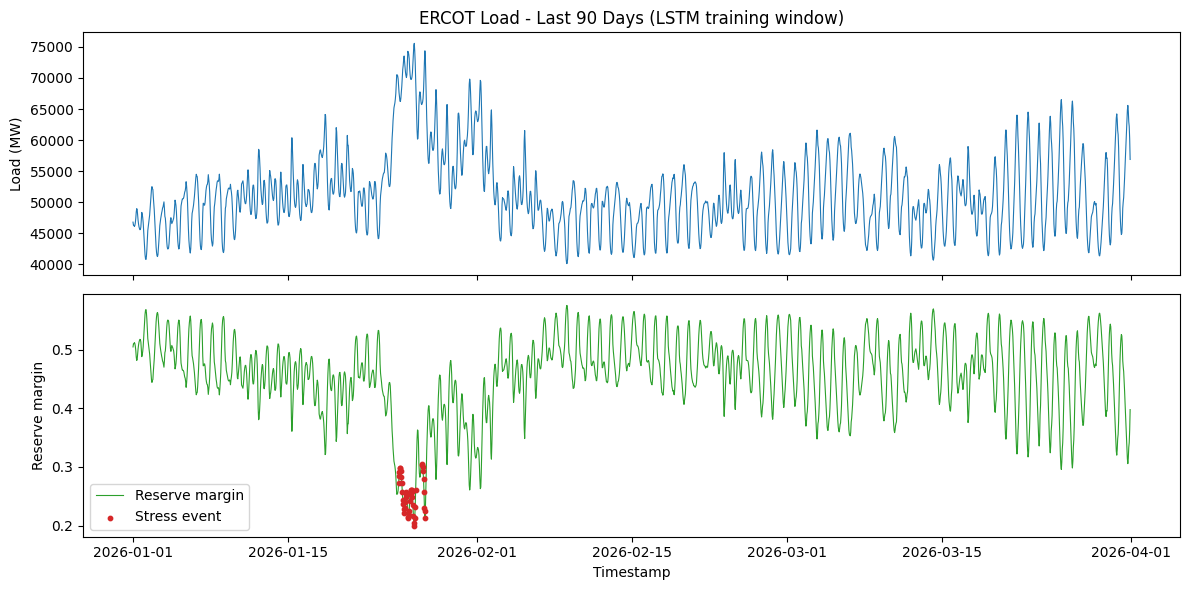


Database exploration complete. Proceed to notebook 02 (LSTM training).


In [5]:
# --- Visualize the last 90 days (the training window for the LSTM) ---
recent = df.set_index('timestamp').last('90D')
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(recent.index, recent['load_mw'], color='#1f77b4', linewidth=0.8)
axes[0].set_ylabel('Load (MW)')
axes[0].set_title('ERCOT Load - Last 90 Days (LSTM training window)')
stress = recent[recent['is_stress_event'] == 1]
axes[1].plot(recent.index, recent['reserve_margin'], color='#2ca02c', linewidth=0.8, label='Reserve margin')
axes[1].scatter(stress.index, stress['reserve_margin'], color='#d62728', s=10, label='Stress event', zorder=5)
axes[1].set_ylabel('Reserve margin')
axes[1].set_xlabel('Timestamp')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

conn.close()
print('\nDatabase exploration complete. Proceed to notebook 02 (LSTM training).')